# SHAP Explainability & Business Insights

This phase focuses on understanding how the final XGBoost fraud detection model makes predictions and identifying the key transaction patterns associated with fraudulent behavior.

While the previous phases focused on model training, tuning, and threshold optimization, this stage is aimed at interpreting the model’s decision-making process and translating the technical results into meaningful business insights.

SHAP (SHapley Additive exPlanations) is used to measure how each feature contributes to the model’s predictions. This helps explain which transaction characteristics increase or decrease the likelihood of fraud and provides better transparency into the model’s behavior.

The main objectives of this phase are:

* Explain how the final XGBoost model detects fraudulent transactions
* Identify the most important fraud-driving transaction features
* Understand how different transaction patterns influence fraud predictions
* Translate technical model outputs into business-focused fraud insights
* Provide practical recommendations for fraud monitoring and risk management

This phase moves the project from model performance evaluation into model interpretation and business understanding, helping connect machine learning predictions to real-world fraud detection behavior.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
%pip install xgboost shap

In [4]:
# =========================
# libraries
# =========================

import joblib
import shap

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from xgboost import XGBClassifier


In [5]:
# =========================
# load saved model
# =========================

best_models = joblib.load("/content/drive/MyDrive/ML_Portfolio/fraud-detection-ml/model/best_models.pkl")

xgb_model = best_models["xgboost"]


# =========================
# load test dataset
# =========================

X_test = joblib.load("/content/drive/MyDrive/ML_Portfolio/fraud-detection-ml/data/processed/X_test_tree.pkl")

y_test = joblib.load("/content/drive/MyDrive/ML_Portfolio/fraud-detection-ml/data/processed/y_test.pkl").squeeze()


# =========================
# quick verification
# =========================

print("X_test shape:", X_test.shape)

print(type(xgb_model))

X_test shape: (200000, 15)
<class 'xgboost.sklearn.XGBClassifier'>


In [6]:
# drop origin_balance_error and destination_balance_error
X_test = X_test.drop(columns=["origin_balance_error", "destination_balance_error"])

In [7]:
y_test

,isFraud
446530,0
729503,0
319109,0
785031,0
118788,0
...,...
652857,0
983083,0
86680,0
571624,0


## SHAP Explainer Initialization

To interpret the prediction behavior of the final XGBoost fraud detection model, a SHAP explainer was created using the trained model and the test dataset.

The explainer computes SHAP values, which represent how much each feature contributes to the model’s predictions. Positive SHAP values push predictions toward fraud, while negative SHAP values reduce the likelihood of a transaction being classified as fraudulent.

This makes it possible to understand how the model uses transaction patterns to make fraud predictions and identify which features have the strongest influence on the final decision.

The SHAP explainer also allows the model to be analyzed at both the global level (overall feature importance across all transactions) and the local level (individual transaction explanations).


In [8]:
# sample test data

X_sample = X_test.sample(2000, random_state=42)

In [13]:
# =========================
# create SHAP explainer
# =========================

explainer = shap.TreeExplainer(xgb_model)


# =========================
# generate SHAP values
# =========================

shap_values = explainer.shap_values(X_test)


# =========================
# quick verification
# =========================

print(type(shap_values))

print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
(200000, 13)


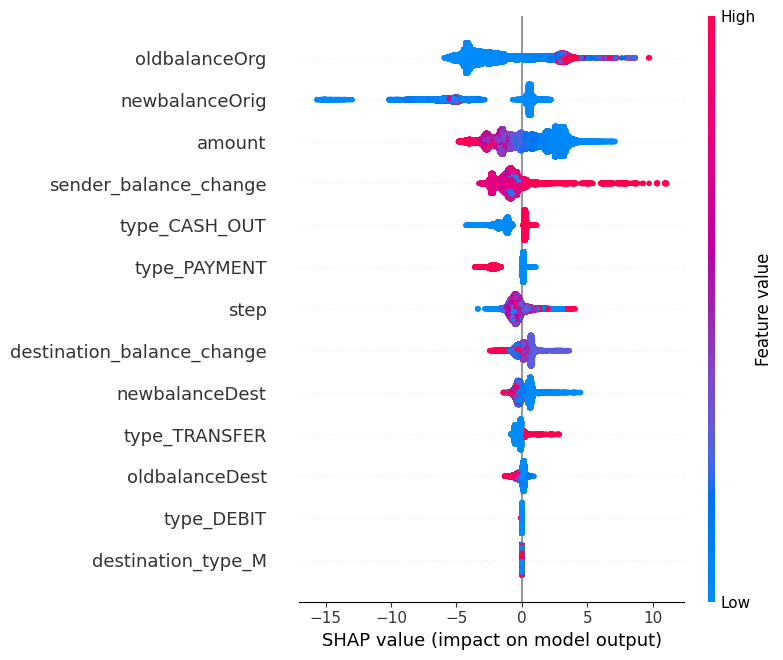

In [14]:
# =========================
# SHAP summary plot
# =========================

shap.summary_plot(shap_values, X_test)

## SHAP Summary Plot

The SHAP summary plot provides a global explanation of the final XGBoost fraud detection model by showing how each feature influences the model’s predictions across different transactions.

Features are ranked based on their overall importance to the model. Features with larger SHAP values have a stronger impact on fraud predictions.

The color distribution represents the original feature values:

* Red indicates higher feature values
* Blue indicates lower feature values

Positive SHAP values push predictions toward fraud, while negative SHAP values reduce the likelihood of fraud classification.

The summary plot shows that account balance variables, transaction amount, sender balance changes, and transaction types were among the most influential features affecting fraud predictions. Features such as `oldbalanceOrg`, `newbalanceOrig`, `amount`, and `sender_balance_change` contributed strongly to the model’s fraud detection decisions.

The visualization also shows that different feature values affect fraud predictions differently. Some high-value transaction patterns increased fraud probability significantly, while more stable balance patterns contributed toward legitimate transaction classification.

Overall, the SHAP summary plot provides insight into how the XGBoost model identifies suspicious transaction behavior and separates fraudulent transactions from legitimate financial activity.


## Business Insights

The SHAP analysis revealed that the XGBoost model relied heavily on transaction balance behavior and transaction type patterns when detecting fraudulent activity.

Sender account balance variables such as `oldbalanceOrg`, `newbalanceOrig`, and `sender_balance_change` were among the strongest fraud-driving features. Large and abnormal balance changes in sender accounts contributed strongly toward fraud predictions, suggesting that fraudulent transactions often involve unusual account depletion behavior.

Transaction type also played an important role in the model’s decision-making process. `CASH_OUT` and `TRANSFER` transactions showed stronger associations with fraud predictions, while `PAYMENT` transactions generally reduced fraud likelihood and appeared more consistent with legitimate financial activity.

The analysis also showed that transaction amount alone was not the strongest fraud indicator. Instead, the model relied more heavily on behavioral transaction patterns and account balance transitions when identifying suspicious activity.

Overall, the model learned meaningful fraud-related transaction behaviors rather than relying on a single dominant feature, making the fraud detection process more realistic and operationally reliable.


## Recommendations

Based on the model results and SHAP analysis, several recommendations can be made to improve fraud monitoring and transaction security systems.

* Financial institutions should pay closer attention to unusual sender balance changes and abnormal account depletion behavior, as these patterns were strongly associated with fraudulent transactions.

* High-risk transaction types such as `TRANSFER` and `CASH_OUT` should receive additional monitoring and risk scoring since they contributed more heavily to fraud predictions.

* Real-time fraud monitoring systems should combine transaction amount analysis with account balance behavior instead of relying on transaction amount alone.

* Dynamic fraud thresholds can be used to balance fraud detection sensitivity and false positive control depending on operational requirements and risk tolerance.

* Transactions flagged with high fraud probability should be routed for additional verification or manual review before final approval.

* Continuous model monitoring and retraining should be implemented to adapt to changing fraud patterns and evolving transaction behavior over time.

Overall, the project demonstrates that machine learning models can effectively support fraud detection systems by identifying suspicious transaction behaviors and improving early fraud identification in highly imbalanced financial datasets.
